## Manual Logistic regression

### IMPORTS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

### SYNTHETIC DATA

In [2]:
np.random.seed(44)
SAMPLE_SIZE = 1000
BOUNDARY = 25  # true decision boundary (mean weight)
TRUE_SLOPE = 1.5  # controls class separation steepness

weight = np.clip(np.random.normal(25, 3, SAMPLE_SIZE), 18, 35)
noise = np.random.normal(0, 1.5, SAMPLE_SIZE)
z_true = TRUE_SLOPE * (weight - BOUNDARY) + noise
is_obese = np.random.binomial(1, 1 / (1 + np.exp(-z_true)), SAMPLE_SIZE)

df = pd.DataFrame({"weight_g": weight, "is_obese": is_obese})

print(f"Samples: {SAMPLE_SIZE}")
print(f"Class 0: {(is_obese==0).sum()} ({(is_obese==0).mean()*100:.1f}%)")
print(f"Class 1: {(is_obese==1).sum()} ({(is_obese==1).mean()*100:.1f}%)")

Samples: 1000
Class 0: 525 (52.5%)
Class 1: 475 (47.5%)


### DATA VISUALIZATION

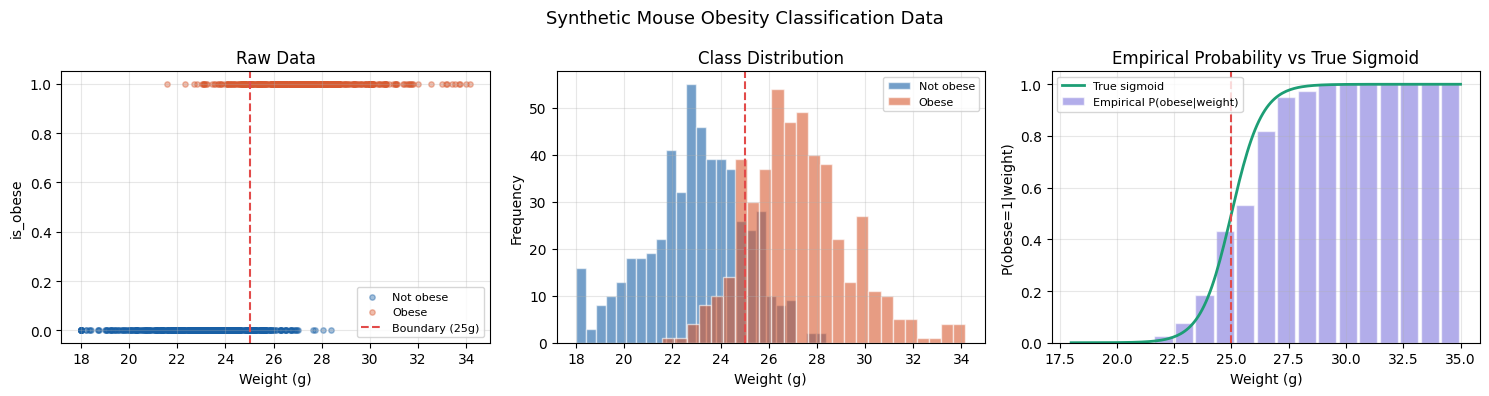

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(
    weight[is_obese == 0],
    is_obese[is_obese == 0],
    alpha=0.4,
    c="#185FA5",
    label="Not obese",
    s=15,
)
axes[0].scatter(
    weight[is_obese == 1],
    is_obese[is_obese == 1],
    alpha=0.4,
    c="#D85A30",
    label="Obese",
    s=15,
)
axes[0].axvline(
    BOUNDARY,
    color="#E24B4A",
    linestyle="--",
    linewidth=1.5,
    label=f"Boundary ({BOUNDARY}g)",
)
axes[0].set(xlabel="Weight (g)", ylabel="is_obese", title="Raw Data")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].hist(
    weight[is_obese == 0],
    bins=25,
    alpha=0.6,
    color="#185FA5",
    label="Not obese",
    edgecolor="white",
)
axes[1].hist(
    weight[is_obese == 1],
    bins=25,
    alpha=0.6,
    color="#D85A30",
    label="Obese",
    edgecolor="white",
)
axes[1].axvline(BOUNDARY, color="#E24B4A", linestyle="--", linewidth=1.5)
axes[1].set(xlabel="Weight (g)", ylabel="Frequency", title="Class Distribution")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

bins = np.linspace(18, 35, 20)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_prob = [
    is_obese[(weight >= bins[i]) & (weight < bins[i + 1])].mean()
    for i in range(len(bins) - 1)
]
xs_sig = np.linspace(18, 35, 200)
true_sig = 1 / (1 + np.exp(-TRUE_SLOPE * (xs_sig - BOUNDARY)))

axes[2].bar(
    bin_centers,
    bin_prob,
    width=0.8,
    alpha=0.6,
    color="#7F77DD",
    label="Empirical P(obese|weight)",
    edgecolor="white",
)
axes[2].plot(xs_sig, true_sig, color="#1D9E75", linewidth=2, label="True sigmoid")
axes[2].axvline(BOUNDARY, color="#E24B4A", linestyle="--", linewidth=1.5)
axes[2].set(
    xlabel="Weight (g)",
    ylabel="P(obese=1|weight)",
    title="Empirical Probability vs True Sigmoid",
)
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle("Synthetic Mouse Obesity Classification Data", fontsize=13)
plt.tight_layout()
plt.show()

### MODEL FUNCTIONS

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_loss(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def compute_gradients(x, y_true, y_pred):
    return np.mean((y_pred - y_true) * x), np.mean(y_pred - y_true)

def update_parameters(m, b, dm, db, lr):
    return m - lr * dm, b - lr * db

### TRAINING LOOP

In [5]:
x = df["weight_g"].values
y = df["is_obese"].values
x_mean = x.mean()
x_std = x.std()
x_norm = (x - x_mean) / x_std

m, b = 0.0, 0.0
learning_rate = 0.01
iterations = 10000
losses = []

for i in range(iterations):
    y_pred = sigmoid(m * x_norm + b)
    loss = log_loss(y, y_pred)
    losses.append(loss)

    dm, db = compute_gradients(x_norm, y, y_pred)
    m, b = update_parameters(m, b, dm, db, learning_rate)

    if i % 100 == 0:
        print(f"Iter {i:>5}: Loss={loss:.4f}  m={m:.4f}  b={b:.4f}")

    if i > 1 and abs(losses[-2] - losses[-1]) < 1e-7:
        print(f"Converged at iteration {i}")
        break

Iter     0: Loss=0.6931  m=0.0036  b=-0.0003
Iter   100: Loss=0.5918  m=0.3198  b=-0.0224
Iter   200: Loss=0.5282  m=0.5704  b=-0.0397
Iter   300: Loss=0.4860  m=0.7749  b=-0.0537
Iter   400: Loss=0.4563  m=0.9465  b=-0.0651
Iter   500: Loss=0.4344  m=1.0938  b=-0.0746
Iter   600: Loss=0.4177  m=1.2226  b=-0.0828
Iter   700: Loss=0.4045  m=1.3368  b=-0.0899
Iter   800: Loss=0.3940  m=1.4393  b=-0.0962
Iter   900: Loss=0.3853  m=1.5321  b=-0.1018
Iter  1000: Loss=0.3781  m=1.6169  b=-0.1068
Iter  1100: Loss=0.3720  m=1.6948  b=-0.1114
Iter  1200: Loss=0.3668  m=1.7667  b=-0.1156
Iter  1300: Loss=0.3623  m=1.8335  b=-0.1195
Iter  1400: Loss=0.3584  m=1.8957  b=-0.1231
Iter  1500: Loss=0.3550  m=1.9540  b=-0.1265
Iter  1600: Loss=0.3520  m=2.0086  b=-0.1296
Iter  1700: Loss=0.3493  m=2.0601  b=-0.1325
Iter  1800: Loss=0.3470  m=2.1086  b=-0.1353
Iter  1900: Loss=0.3448  m=2.1545  b=-0.1380
Iter  2000: Loss=0.3429  m=2.1980  b=-0.1405
Iter  2100: Loss=0.3412  m=2.2393  b=-0.1428
Iter  2200

### EVALUATION

In [6]:
y_pred = sigmoid(m * x_norm + b)
y_pred_label = (y_pred >= 0.5).astype(int)
accuracy = np.mean(y_pred_label == y)

m_raw = m / x_std
b_raw = b - m * x_mean / x_std
boundary_learned = -b_raw / m_raw

print(f"\nFinal loss:       {log_loss(y, y_pred):.4f}")
print(f"Accuracy:         {accuracy*100:.2f}%")
print(f"Learned boundary: {boundary_learned:.2f}g  (true: {BOUNDARY}g)")
print(f"Learned slope:    {m_raw:.4f}  (true: {TRUE_SLOPE})")


Final loss:       0.3203
Accuracy:         84.30%
Learned boundary: 25.17g  (true: 25g)
Learned slope:    1.1059  (true: 1.5)


### LOSS CURVE

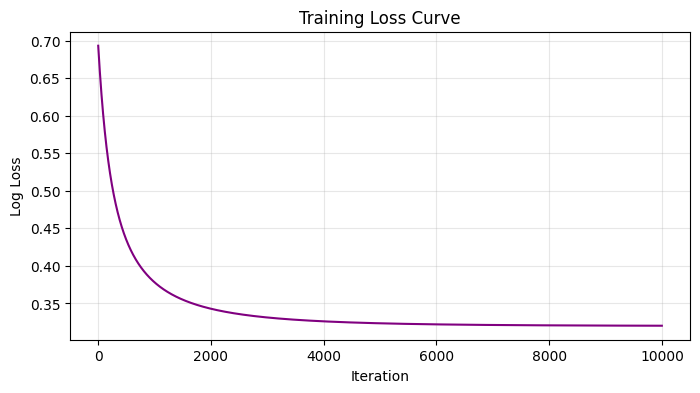

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(losses, color="purple")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.title("Training Loss Curve")
plt.grid(True, alpha=0.3)
plt.show()

### DECISION BOUNDARY PLOT

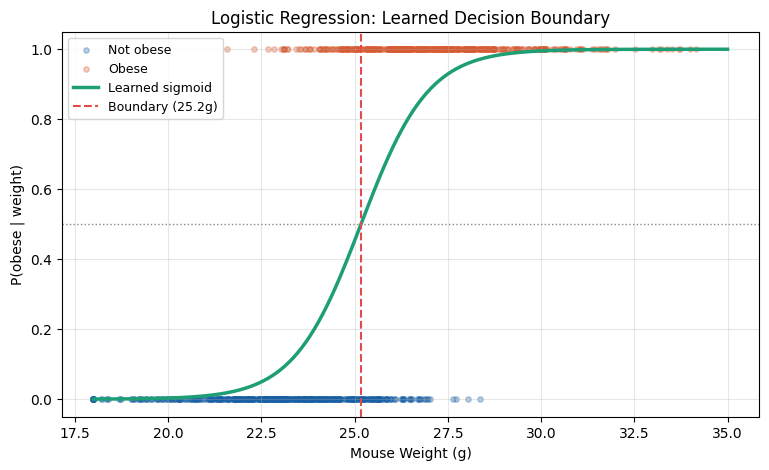

In [8]:
x_line = np.linspace(18, 35, 300)
x_line_norm = (x_line - x_mean) / x_std
y_line = sigmoid(m * x_line_norm + b)

plt.figure(figsize=(9, 5))
plt.scatter(x[y == 0], y[y == 0], alpha=0.3, c="#185FA5", s=15, label="Not obese")
plt.scatter(x[y == 1], y[y == 1], alpha=0.3, c="#D85A30", s=15, label="Obese")
plt.plot(x_line, y_line, color="#1D9E75", linewidth=2.5, label="Learned sigmoid")
plt.axvline(
    boundary_learned,
    color="#E24B4A",
    linestyle="--",
    linewidth=1.5,
    label=f"Boundary ({boundary_learned:.1f}g)",
)
plt.axhline(0.5, color="#888780", linestyle=":", linewidth=1)
plt.xlabel("Mouse Weight (g)")
plt.ylabel("P(obese | weight)")
plt.title("Logistic Regression: Learned Decision Boundary")
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()

### SKLEARN COMPARISON

In [9]:
reg = LogisticRegression(C=1e9, max_iter=10000).fit(x.reshape(-1, 1), y)
m_sk = reg.coef_[0][0]
b_sk = reg.intercept_[0]
loss_sk = log_loss(y, reg.predict_proba(x.reshape(-1, 1))[:, 1])

print(f"\n{'':>10} {'Slope':>10} {'Intercept':>12} {'Log Loss':>10}")
print(f"{'Scratch':>10} {m_raw:>10.4f} {b_raw:>12.4f} {log_loss(y,y_pred):>10.4f}")
print(f"{'Sklearn':>10} {m_sk:>10.4f} {b_sk:>12.4f} {loss_sk:>10.4f}")


                Slope    Intercept   Log Loss
   Scratch     1.1059     -27.8389     0.3203
   Sklearn     1.1652     -29.3314     0.3200


### MODEL COMPARISON PLOT

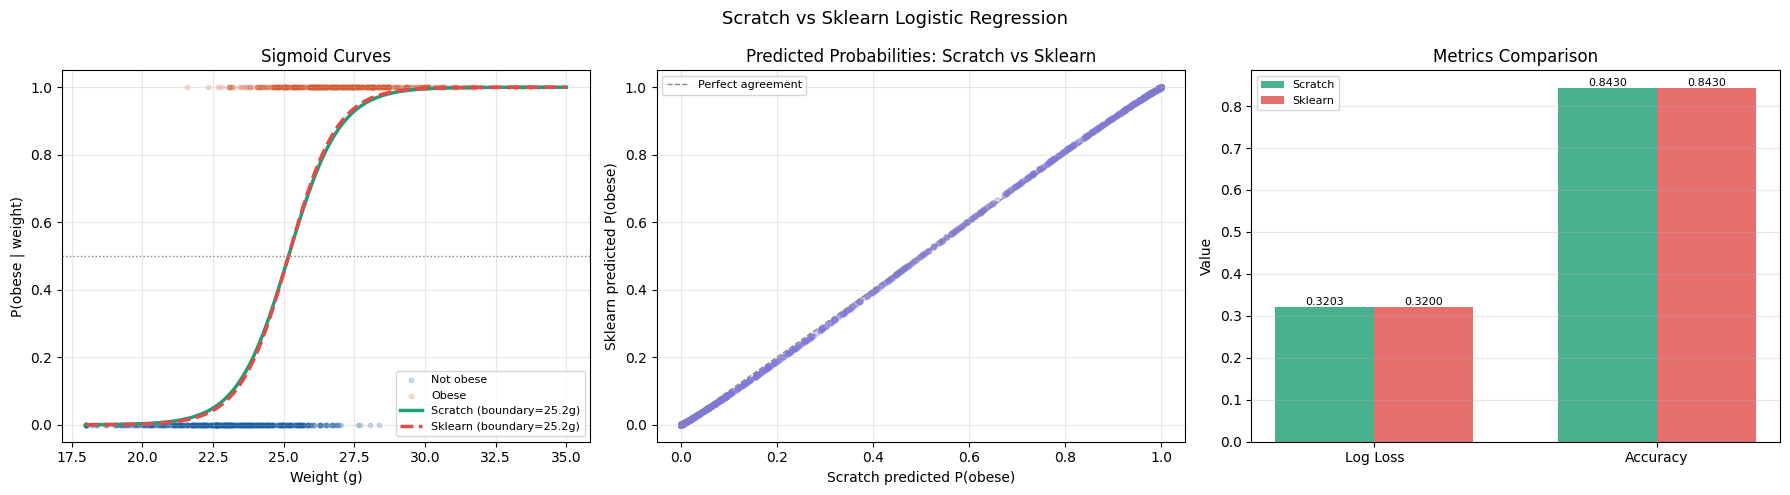

In [10]:
x_line = np.linspace(18, 35, 300)
x_line_norm = (x_line - x_mean) / x_std

y_scratch = sigmoid(m * x_line_norm + b)
y_sklearn = 1 / (1 + np.exp(-(m_sk * x_line + b_sk)))

boundary_sk = -b_sk / m_sk

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Sigmoid curves overlaid ───────────────────────
axes[0].scatter(x[y==0], y[y==0], alpha=0.2, c="#185FA5", s=10, label="Not obese")
axes[0].scatter(x[y==1], y[y==1], alpha=0.2, c="#D85A30", s=10, label="Obese")
axes[0].plot(x_line, y_scratch, color="#1D9E75", linewidth=2.5, label=f"Scratch (boundary={boundary_learned:.1f}g)")
axes[0].plot(x_line, y_sklearn, color="#E24B4A", linewidth=2.5, linestyle="--", label=f"Sklearn (boundary={boundary_sk:.1f}g)")
axes[0].axhline(0.5, color="#888780", linestyle=":", linewidth=1)
axes[0].set(xlabel="Weight (g)", ylabel="P(obese | weight)", title="Sigmoid Curves")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# ── Plot 2: Predicted probabilities scatter ────────────────
y_pred_sk = reg.predict_proba(x.reshape(-1, 1))[:, 1]
axes[1].scatter(y_pred, y_pred_sk, alpha=0.3, s=15, c="#7F77DD")
axes[1].plot([0,1], [0,1], color="#888780", linestyle="--", linewidth=1, label="Perfect agreement")
axes[1].set(xlabel="Scratch predicted P(obese)",
            ylabel="Sklearn predicted P(obese)",
            title="Predicted Probabilities: Scratch vs Sklearn")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# ── Plot 3: Summary bar chart ──────────────────────────────
acc_sk    = np.mean((y_pred_sk >= 0.5).astype(int) == y)
loss_scr  = log_loss(y, y_pred)
loss_sk_v = log_loss(y, y_pred_sk)

metrics       = ["Log Loss", "Accuracy"]
scratch_vals  = [loss_scr,  accuracy]
sklearn_vals  = [loss_sk_v, acc_sk]

bar_x = np.arange(len(metrics))
width = 0.35
axes[2].bar(bar_x - width/2, scratch_vals, width, color="#1D9E75", alpha=0.8, label="Scratch")
axes[2].bar(bar_x + width/2, sklearn_vals, width, color="#E24B4A", alpha=0.8, label="Sklearn")

for i, (sv, skv) in enumerate(zip(scratch_vals, sklearn_vals)):
    axes[2].text(i - width/2, sv + 0.005, f"{sv:.4f}", ha="center", fontsize=8)
    axes[2].text(i + width/2, skv + 0.005, f"{skv:.4f}", ha="center", fontsize=8)

axes[2].set_xticks(bar_x)
axes[2].set_xticklabels(metrics)
axes[2].set(ylabel="Value", title="Metrics Comparison")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3, axis="y")

plt.suptitle("Scratch vs Sklearn Logistic Regression", fontsize=13)
plt.tight_layout()
plt.show()

## Conclusion

Here we implemented Manual Logistic regression which results similar to scikit‑learn Logistic Regression.